# **Project** 1

### How well can you predict which brain region a neuron is in based on its activity?

This dataset surveyed visual responses across six different visual areas. One of the key questions we can ask is how the neural responses differ across these areas? There have been several studies that have looked at this, both using these data as well as other data. Two papers that motivated this study were published back-to-back: [Marshel, Garrett et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01046-4?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010464%3Fshowall%3Dtrue) and [Andermann et al 2011](https://www.cell.com/neuron/fulltext/S0896-6273(11)01012-9?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0896627311010129%3Fshowall%3Dtrue). These two studies compared the tuning properties of neurons in different areas in the mouse visual cortex. They compared area responses using metrics such as orientation selectivity, preferred temporal frequency (TF), and preferred spatial frequency (SF).  Andermann et al particularly focused on the differences between areas AL and PM as these are thought to be parts of the ventral and dorsal visual streams, respectively. [see lecture slides X-Y]

Another notable study, [Kumar et al 2021](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1008548), uses the Allen Brain Observatory data to show that neurons can be parcellated into brain regions using short segments of natural movie responses or even spontaneous activity.

The question here is how accurately can you classify neurons into their respective brain regions based on their responses to the drifting grating stimulus?


In [2]:
# @title Run to initialize Allen Brain Observatory on Colab {display-mode: "form" }

# run only once per runtime/session, and only if running in colab
# the runtime will need to restxart after
%%capture
!apt install s3fs

!pip uninstall -y numpy pandas
!pip install git+https://github.com/AllenInstitute/AllenSDK@1bdca3ad884c3a5edea8236161424650603e6f29 "numpy == 1.26.4" "pandas == 2.3.0" "matplotlib > 3.8.0" "statsmodels >= 0.14.4"
import allensdk
print('allensdk imported successfully')

!mkdir -p /data/allen-brain-observatory/
!s3fs allen-brain-observatory /data/allen-brain-observatory/ -o public_bucket=1

import time
print("Runtime is now restarting...")
print("You can ignore the error message [Your session crashed for an unknown reason.]")
time.sleep(5)
exit()


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, confusion_matrix

Set up the AllenSDK and point it to the data manifest

In [3]:
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

In [4]:
import platform, os, sys
platstring = platform.platform()

if ('amzn' in platstring) or ('google.colab' in sys.modules):
    # for AWS
    vc_cache_dir = '/data/allen-brain-observatory/visual-coding-2p'
else:
    # for local drive, different operating systems
    if ('Darwin' in platstring) or ('macOS' in platstring):
        # OS X
        data_root = "/Volumes/TReND2026/"
    elif 'Windows'  in platstring:
        # Windows (replace with the drive letter of USB drive)
        data_root = "E:/"
    else:
        # your own linux platform
        # EDIT location where you mounted hard drive
        data_root = "/media/$USERNAME/TReND2026/"

    # visual behavior cache directory
    vc_cache_dir = os.path.join(data_root, "allen-brain-observatory","visual-coding-2p")

boc = BrainObservatoryCache(manifest_file=os.path.join(vc_cache_dir, 'manifest.json'))

Get a dataframe of sessions in VISpm, layer 2/3 Cux2 when drifting gratings were shown

In [5]:
exps_pm = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISpm'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

Look at the data frame. How long is it?

In [6]:
exps_pm.head()

,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,504115289,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),124,511510817,three_session_A,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True
1,502666254,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),96,511510645,three_session_A,225039,Cux2-CreERT2;Camk2a-tTA;Ai93-225039,True
2,658854537,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),110,658854535,three_session_A,360566,Cux2-CreERT2;Camk2a-tTA;Ai93-360566,False
3,512311673,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),91,511976252,three_session_A,233214,Cux2-CreERT2;Camk2a-tTA;Ai93-233214,True
4,510859641,175,VISpm,Cux2-CreERT2,Ai93(TITL-GCaMP6f),82,511511083,three_session_A,233215,Cux2-CreERT2;Camk2a-tTA;Ai93-233215,False


In [7]:
len(exps_pm)

9

Now repeat this to get a dataframe of sessions in VISal, layer 2/3 Cux2 when drifting gratings were shown

In [8]:
exps_al = pd.DataFrame(boc.get_ophys_experiments(targeted_structures=['VISal'],
                                              cre_lines=['Cux2-CreERT2'],
                                              imaging_depths=[175],
                                             stimuli=['drifting_gratings']))

In [9]:
len(exps_al)

6

In tutorial 2 we wrote a function to compute the tuning curves for all the neurons in a single session. Copy and paste that here:

In [10]:
def compute_tuning(session_id):
    """
    Computes the 2D tuning array for all neurons in a given session
    for drifting gratings stimulus.

    Parameters
    ----------
    session_id : int
        The session id for one session.

    Returns
    -------
    dff : numpy.ndarray
        Delta F over F traces for all cells.
    stim_table : pandas.DataFrame
        Stimulus table for drifting gratings.
    trial_response : pandas.DataFrame
        Response per trial for all neurons.
    tuning_array : numpy.ndarray
        2D tuning array for all neurons, with dimensions (orientation, temporal_frequency, cell index).
    """
    #access data for the session
    data_set = boc.get_ophys_experiment_data(session_id)

    #get the DFF trace for all cells
    timestamps, dff = data_set.get_dff_traces()
    number_cells = dff.shape[0]
    print("Number of cells: ", number_cells)

    #get the stimulus table for the drifting gratings
    stim_table = data_set.get_stimulus_table('drifting_gratings')

    #get the orivals and tfvals
    all_ori = np.unique(stim_table.orientation)
    orivals = all_ori[np.isfinite(all_ori)]
    tfvals = np.unique(stim_table.temporal_frequency)
    tfvals = tfvals[np.isfinite(tfvals)]

    #compute response per trial for all neurons
    trial_response = pd.DataFrame(index=stim_table.index.values, columns=np.array(range(number_cells)).astype(str))

    for ind,row in stim_table.iterrows():
        for nc in range(number_cells):
            trial_response.loc[ind, str(nc)] = dff[nc,int(row.start):int(row.end)].mean()

    #calculate the response to the blanksweeps:
    blank_response = trial_response[np.isnan(stim_table.orientation)].mean()

    #compute 2D tuning array and subtract the blanksweep response
    tuning_array = np.empty((8,5,number_cells))
    for i,tf in enumerate(tfvals): #iterate across TF
        for j,ori in enumerate(orivals): #iterate across ori
            tuning_array[j,i,:] = trial_response[(stim_table.orientation==ori)&
                                                 (stim_table.temporal_frequency==tf)].mean() - blank_response

    return(dff, stim_table, trial_response, tuning_array)

Let's test this on the first session in our exps_pm list

In [11]:
session_id = exps_pm.id[0]
(dff, stim_table, trial_response, tuning_array) = compute_tuning(session_id)
print("example session:", session_id)
print("dff            :", dff.shape, "= (n_cells, n_timepoints)  raw calcium traces")
print("stim_table     :", stim_table.shape, "= (n_presentations, columns)  what/when was shown")
print("trial_response :", trial_response.shape, "= (n_trials, n_cells)  one response per trial per cell")
print("tuning_array   :", tuning_array.shape, "= (8 ori, 5 TF, n_cells)  trial-averaged tuning")

Number of cells:  94
example session: 504115289
dff            : (94, 115470) = (n_cells, n_timepoints)  raw calcium traces
stim_table     : (628, 5) = (n_presentations, columns)  what/when was shown
trial_response : (628, 94) = (n_trials, n_cells)  one response per trial per cell
tuning_array   : (8, 5, 94) = (8 ori, 5 TF, n_cells)  trial-averaged tuning


**(a) `dff` - the raw signal.** This is fluorescence over time for every neuron: the closest thing to "what the microscope saw". Bumps are calcium events (roughly, spiking). Everything else is derived from this.

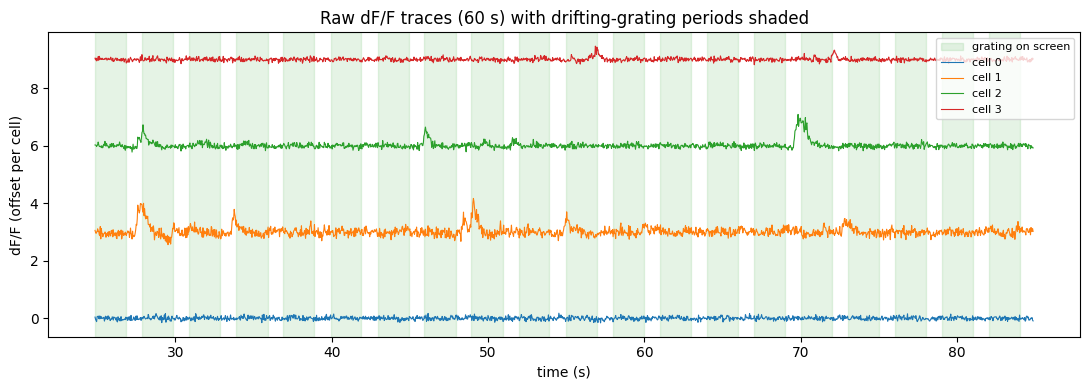

In [12]:
# plot a 60 s window of a few example neurons (assume ~30 Hz imaging).
# start the window at the first drifting-grating presentation so the stimulus is visible.
fs = 30
t = np.arange(dff.shape[1]) / fs
t0_win = stim_table.start.min() / fs        # first grating presentation (in seconds)
t1_win = t0_win + 60
window = (t >= t0_win) & (t < t1_win)

plt.figure(figsize=(11, 4))

# shade each interval when a grating is ON screen (blank/grey-screen gaps stay unshaded)
first = True
for _, row in stim_table.iterrows():
    a, b = row.start / fs, row.end / fs
    if b < t0_win or a > t1_win or not np.isfinite(row.orientation):
        continue
    plt.axvspan(max(a, t0_win), min(b, t1_win), color="tab:green", alpha=0.12,
                label="grating on screen" if first else None)
    first = False

for k, cell in enumerate([0, 1, 2, 3]):
    plt.plot(t[window], dff[cell, window] + k * 3, lw=0.8, label=f"cell {cell}")
plt.xlabel("time (s)"); plt.ylabel("dF/F (offset per cell)")
plt.title("Raw dF/F traces (60 s) with drifting-grating periods shaded")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

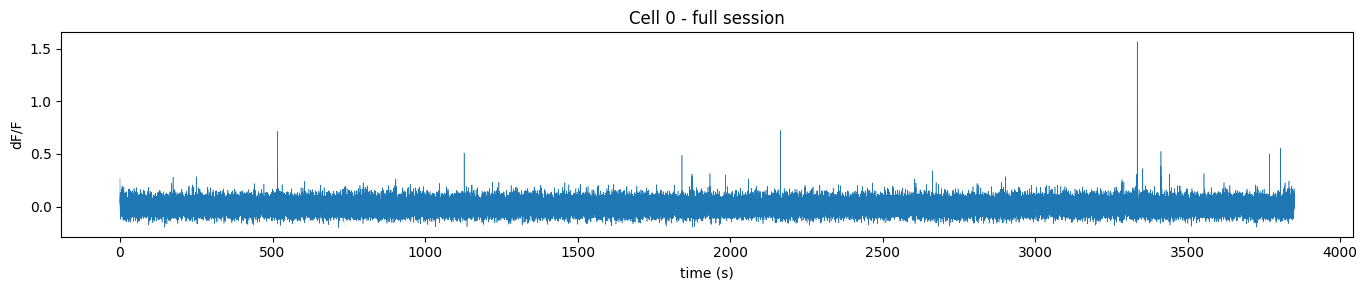

In [13]:
plt.figure(figsize=(14, 3))
plt.plot(t, dff[0], lw=0.4)
plt.xlabel("time (s)"); plt.ylabel("dF/F")
plt.title("Cell 0 - full session"); plt.tight_layout(); plt.show()

**(b) `stim_table` - the stimulus log.** Each row is one grating presentation: its `orientation`, `temporal_frequency`, and the `start`/`end` frame indices into `dff`. Rows with `NaN` orientation are **blank sweeps** (grey screen) - our baseline. There are **8 orientations x 5 temporal frequencies = 40 conditions**, each repeated many times.

In [14]:
print("orientations (deg):", np.unique(stim_table.orientation.dropna().values))
print("temporal freqs (Hz):", np.unique(stim_table.temporal_frequency.dropna().values))
print("total presentations:", len(stim_table),
      "| blank sweeps:", int(stim_table.orientation.isna().sum()))
stim_table.head(20)

orientations (deg): [  0.  45.  90. 135. 180. 225. 270. 315.]
temporal freqs (Hz): [ 1.  2.  4.  8. 15.]
total presentations: 628 | blank sweeps: 29


,temporal_frequency,orientation,blank_sweep,start,end
0,8.0,225.0,0.0,746,806
1,4.0,270.0,0.0,836,896
2,15.0,45.0,0.0,927,986
3,4.0,180.0,0.0,1017,1077
4,1.0,270.0,0.0,1107,1167
5,1.0,180.0,0.0,1198,1257
6,8.0,315.0,0.0,1288,1348
7,15.0,225.0,0.0,1378,1438
8,1.0,180.0,0.0,1468,1528
9,15.0,135.0,0.0,1559,1618


**(c) `trial_response` - one number per trial per cell.** For each presentation we averaged the neuron's `dF/F` over that grating's frames.


In [15]:
trial_response


,0,1,2,3,4,5,6,7,8,9,...,84,85,86,87,88,89,90,91,92,93
0,-0.003774,-0.046146,0.00348,0.007597,0.002234,0.017076,-0.000597,0.621905,0.004734,0.009445,...,0.006201,0.007017,0.004126,0.002801,0.004843,-0.004283,-0.002296,0.01354,-0.016526,0.003265
1,0.015337,0.08078,0.09196,0.004334,0.007513,0.009025,-0.002539,0.005211,0.0075,-0.011793,...,-0.010271,0.033906,-0.008921,0.014317,-0.004726,0.001848,0.137626,0.011823,0.006653,0.010998
2,0.01313,0.011891,0.031203,0.01111,-0.002808,0.004733,0.00429,-0.015928,0.036006,-0.01539,...,0.027458,0.008417,0.012975,0.015436,0.015581,-0.002154,-0.005524,0.006384,0.010906,0.005963
3,0.017919,0.017461,0.020195,0.001348,0.009283,0.008555,0.013668,0.548611,0.004279,0.040302,...,0.004644,0.008389,-0.002557,-0.004076,0.000219,0.011717,-0.003268,0.007107,-0.012456,0.005878
4,0.00964,-0.002019,0.014111,0.007739,0.006223,-0.002296,-0.00512,-0.01408,-0.004938,0.041112,...,0.008082,0.00537,0.011522,-0.001534,0.009408,-0.001442,0.010765,0.006456,0.208841,0.004207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
623,-0.009422,-0.002567,-0.005276,0.001226,0.006677,0.006262,-0.004975,0.403576,-0.001064,-0.017446,...,0.003264,0.000897,-0.002041,-0.001164,-0.005097,0.005197,0.001646,0.003023,-0.002774,0.000973
624,-0.001589,0.076341,0.001366,0.003848,0.019324,0.010035,-0.006389,0.919535,0.009233,0.055869,...,0.001359,0.002911,-0.000171,0.00868,-0.008459,0.013521,0.003012,0.006319,0.001134,0.001071
625,-0.004386,-0.025171,0.008922,0.005243,-0.004542,-0.008358,0.00255,0.650277,-0.00341,0.00145,...,0.007068,-0.001556,-0.002229,0.011383,0.00013,0.003832,-0.003322,0.005383,0.004748,0.008852
626,-0.009002,0.007601,-0.002382,-0.010139,-0.002972,0.010982,-0.003271,0.202183,-0.004327,-0.004169,...,-0.004166,0.012845,0.001339,0.007509,-0.001506,0.008246,0.000632,-0.008206,-0.006177,-0.002823


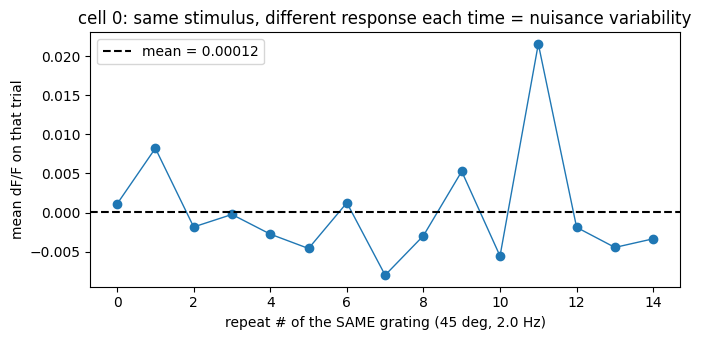

In [16]:
# pick one cell and one condition; show how much its response varies across repeats
# Interpreting one point: if the dot at x = 3 sits at y = 0.19, that reads as:
#"the 4th time cell 0 saw the 45°/2 Hz grating, its average dF/F over that trial was 0.19.
cell = 0
ori0, tf0 = 45.0, 2.0
mask = (stim_table.orientation == ori0) & (stim_table.temporal_frequency == tf0)
repeats = trial_response.loc[mask.values, str(cell)].astype(float).values

plt.figure(figsize=(7, 3.5))
plt.plot(repeats, "o-", lw=1)
plt.axhline(repeats.mean(), color="k", ls="--", label=f"mean = {repeats.mean():.5f}")
plt.xlabel(f"repeat # of the SAME grating ({int(ori0)} deg, {tf0} Hz)")
plt.ylabel("mean dF/F on that trial")
plt.title(f"cell {cell}: same stimulus, different response each time = nuisance variability")
plt.legend(); plt.tight_layout(); plt.show()

**(d) `tuning_array` - the trial-averaged summary.** For each of the 40 conditions we averaged over repeats and subtracted the blank. The result, `(8 orientations x 5 TF x n_cells)`, is each neuron's **tuning**: how strongly it responds to each grating. Averaging over repeats is exactly the step that removes the trial-to-trial nuisance and keeps the reliable signal.

What's the shape of this array? Remind yourself what these axes are.

In [17]:
tuning_array.shape
# tuning_array[:, :, :]

(8, 5, 94)

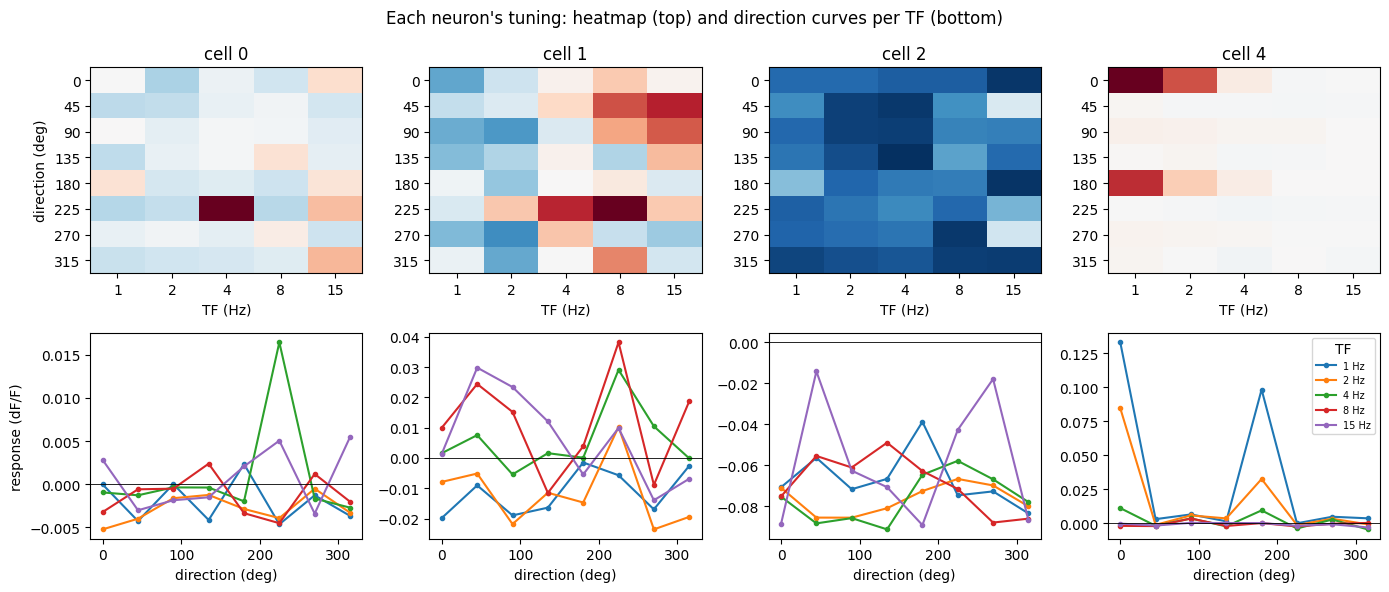

In [18]:
dirs_deg = np.arange(0, 360, 45)          # 8 directions
tfvals   = np.array([1., 2., 4., 8., 15.]) # 5 temporal frequencies (Hz)

example_cells = [0, 1, 2, 4]
fig, axes = plt.subplots(2, len(example_cells), figsize=(14, 6))
for k, cell in enumerate(example_cells):
    g = tuning_array[:, :, cell]           # (8 dir, 5 TF)

    # top row: heatmap
    ax = axes[0, k]
    im = ax.imshow(g, cmap="RdBu_r", vmin=-np.abs(g).max(), vmax=np.abs(g).max(), aspect="auto")
    ax.set_xticks(range(5)); ax.set_xticklabels(tfvals.astype(int))
    ax.set_yticks(range(8)); ax.set_yticklabels(dirs_deg)
    ax.set_title(f"cell {cell}")
    if k == 0: ax.set_ylabel("direction (deg)")
    ax.set_xlabel("TF (Hz)")

    # bottom row: tuning CURVES (response vs direction, one line per TF)
    ax = axes[1, k]
    for j, tf in enumerate(tfvals):
        ax.plot(dirs_deg, g[:, j], marker="o", ms=3, label=f"{int(tf)} Hz")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_xlabel("direction (deg)")
    if k == 0: ax.set_ylabel("response (dF/F)")
    if k == len(example_cells) - 1: ax.legend(fontsize=7, title="TF")

fig.suptitle("Each neuron's tuning: heatmap (top) and direction curves per TF (bottom)")
plt.tight_layout(); plt.show()

Text(0.5, 1.0, 'Cell 4')

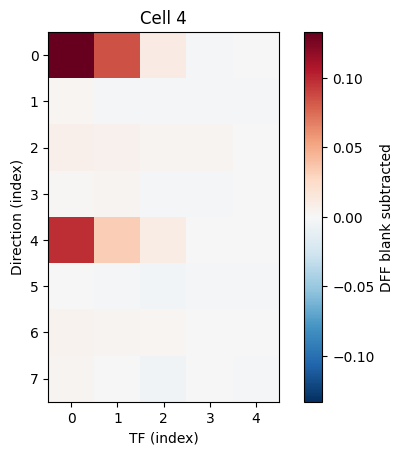

In [19]:
cell_id=4 #pick a cell index
plt.imshow(tuning_array[:,:,cell_id], cmap='RdBu_r', vmax=tuning_array[:,:,cell_id].max(), vmin=-1*tuning_array[:,:,cell_id].max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of

We want to use this 2-dimensional tuning array to predict what brain region the neuron belonged to. This is easier if we can turn this 2D array into a 1D vector. To do that we'll use the function `np.reshape` to flatten our tuning_array.

In [20]:
ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])

Now look at the shape of the resulting array. What are these dimensions?

In [21]:
ta_flatten.shape

(40, 94)

Let's plot the flattened tuning array for the same neuron as above.

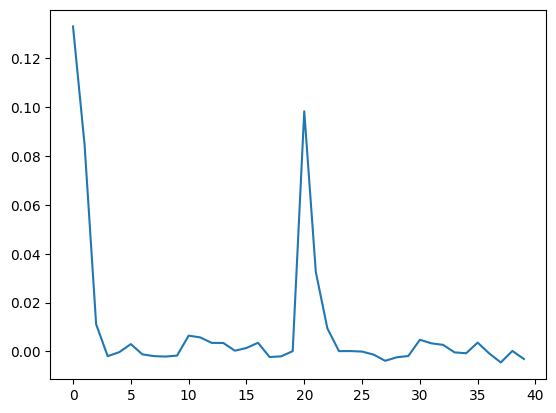

In [22]:
plt.plot(ta_flatten[:,cell_id])

And, for completeness, you can restore the original 2D tuning curve using the `np.reshape` function.

In [23]:
ta_reshape = ta_flatten[:,cell_id].reshape((8,5)) #this reshapes just our chosen neuron

Plot this to confirm we have the same original plot:

Text(0.5, 1.0, 'Cell 4')

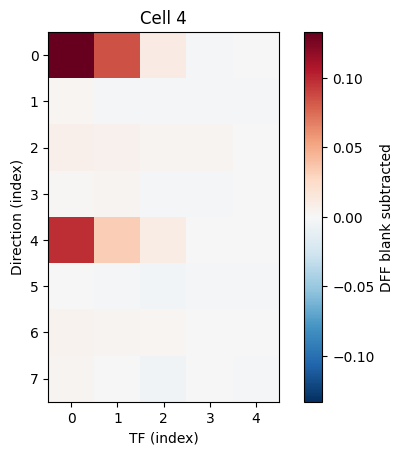

In [24]:
plt.imshow(ta_reshape[:,:], cmap='RdBu_r', vmax=ta_reshape.max(), vmin=-1*ta_reshape.max())

plt.xlabel("TF (index)")
plt.ylabel("Direction (index)")

cbar = plt.colorbar()
cbar.set_label("DFF blank subtracted")
plt.title("Cell "+str(cell_id)) #Add a title so we know what the plot is of



---



Okay, now that we've demonstrated what we want to do for all the neurons, let's
get to business!

Use function to compute 2D tuning array for all PM sessions. Flatten the tuning array from the session, and append the result to a growing list of tuning data.

In [25]:
#create an empty array to contain the results
tuning_pm = np.empty((40,0))
session_pm = []  # track which session each neuron came from (needed for grouped CV)

#for each session
for pmid in exps_pm.id:
    print("Session ID: ", pmid)
    #compute the 2D tuning array
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(pmid)
    #flatten the array from (8,5,numbercells) to (40,numbercells)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    #append the result to the array for results
    tuning_pm = np.append(tuning_pm, ta_flatten, axis=1)
    #record this session's id once per neuron it contributed
    session_pm.extend([pmid] * ta_flatten.shape[1])

Session ID:  504115289
Number of cells:  94
Session ID:  502666254
Number of cells:  90
Session ID:  658854537
Number of cells:  112
Session ID:  512311673
Number of cells:  70
Session ID:  510859641
Number of cells:  124
Session ID:  503324629
Number of cells:  167
Session ID:  657914280
Number of cells:  84
Session ID:  502376461
Number of cells:  106
Session ID:  506773185
Number of cells:  101


What is the shape of your resulting array?

In [26]:
tuning_pm.shape

(40, 948)

Repeat this for the AL data.

In [27]:
tuning_al = np.empty((40,0))
session_al = []  # track which session each neuron came from (needed for grouped CV)

for alid in exps_al.id:
    print("Session ID: ", alid)
    (dff, stim_table, trial_response, tuning_array) = compute_tuning(alid)
    ta_flatten = tuning_array.reshape(-1,tuning_array.shape[-1])
    tuning_al = np.append(tuning_al, ta_flatten, axis=1)
    session_al.extend([alid] * ta_flatten.shape[1])

Session ID:  506773892
Number of cells:  76
Session ID:  557225279
Number of cells:  47
Session ID:  503412730
Number of cells:  119
Session ID:  502199136
Number of cells:  159
Session ID:  501876401
Number of cells:  181
Session ID:  501933264
Number of cells:  217


What is the shape of this array?

In [28]:
tuning_al.shape

(40, 799)

## 4. Signal vs nuisance: what actually differs between the areas?

Before modelling, we look at the **average tuning of each area**. If PM and AL differ on average, that difference is the *signal* a decoder can use. Anything that varies neuron-to-neuron or session-to-session but not systematically by area is *nuisance*.

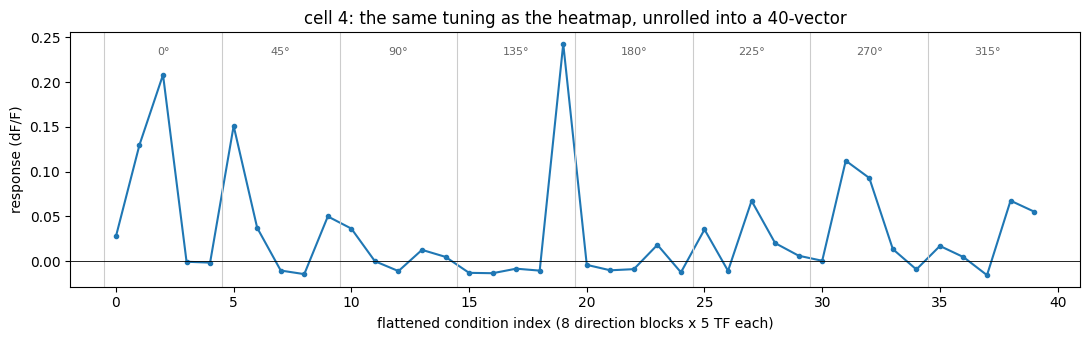

In [29]:
# plot one neuron's 40-vector; mark the 8 direction blocks (5 TFs each)
cell_id = 4
plt.figure(figsize=(11, 3.5))
plt.plot(ta_flatten[:, cell_id], marker="o", ms=3)
for d in range(8):
    plt.axvline(d * 5 - 0.5, color="0.8", lw=0.8)        # block boundary
    plt.text(d * 5 + 2, plt.ylim()[1] * 0.9, f"{d*45}\u00b0", ha="center", fontsize=8, color="0.4")
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("flattened condition index (8 direction blocks x 5 TF each)")
plt.ylabel("response (dF/F)")
plt.title(f"cell {cell_id}: the same tuning as the heatmap, unrolled into a 40-vector")
plt.tight_layout(); plt.show()



---
Now that we have our tuning arrays for all the neurons in PM and AL, we want to create a labels for each neuron. We'll label PM as 0 and AL as 1.



In [30]:
label = np.repeat(0,tuning_pm.shape[1]) #create a vector of 0's as long as the PM neurons
label = np.append(label, np.repeat(1,tuning_al.shape[1])) #append a vector of 1's as long as the AL neurons
len(label)

1747

Plot this to confirm it looks like you expect.

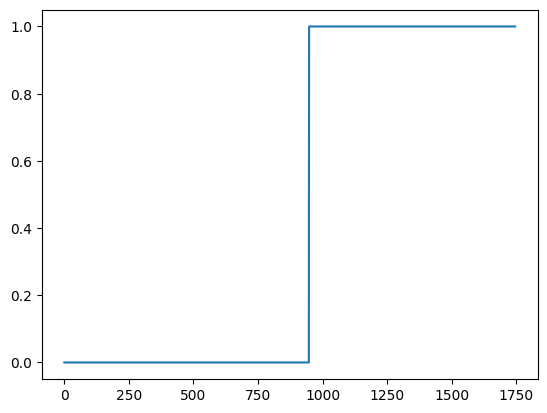

In [31]:
plt.plot(label)

Now let's append the two tuning arrays together. Do PM first and then AL to match the labels.

In [32]:
tuning = np.append(tuning_pm, tuning_al, axis=1)

In [33]:
tuning.shape

(40, 1747)

Notice that our label vector is as long as our tuning array.

The challenge in this project is to use classification methods to determine the correct label for a neuron based on its tuning. You can try a variety of methods and determine which ones work best, and how well you can differentiate these two regions (it won't be perfect!).

You will want to set up some hold out data to test your classification methods. So let's do that now. We will create a random list of integers to remove from these arrays. First, set a seed so that we create the same random selection if we rerun this code. Set the seed variable with your favorite number.

In [34]:
# Create a generator instance with a specific seed. Feel free to change the seed to the number of your choosing
rng = np.random.default_rng(seed=0)

Now get random numbers from the range of the number of neurons we have here. We'll select 200 neurons - but you can change this if you want to hold out more or less data.
This serves as an index into your tuning array and label vector.

In [35]:
total_cells = len(label)
holdout_length = 200
holdout = np.random.choice(range(total_cells), holdout_length, replace=False)

Use this to separate your tuning and label into a holdout set and a training set.

In [36]:
tuning_holdout = tuning[:,holdout]
tuning_holdout.shape

(40, 200)

In [37]:
tuning_train = np.delete(tuning, holdout, axis=1)
tuning_train.shape

(40, 1547)

In [38]:
label_holdout = label[holdout]
label_holdout.shape

(200,)

In [39]:
label_train = np.delete(label, holdout)
len(label_train)

1547

From here, use your tuning_train and label_train to train classifier to best predict the brain region that each neuron is from. Sklearn has a number of classification methods that you can use and compare.


## 4. Signal vs nuisance: what actually differs between the areas?

Before modelling, we look at the **average tuning of each area**. If PM and AL differ on average, that difference is the *signal* a decoder can use. Anything that varies neuron-to-neuron or session-to-session but not systematically by area is *nuisance*.

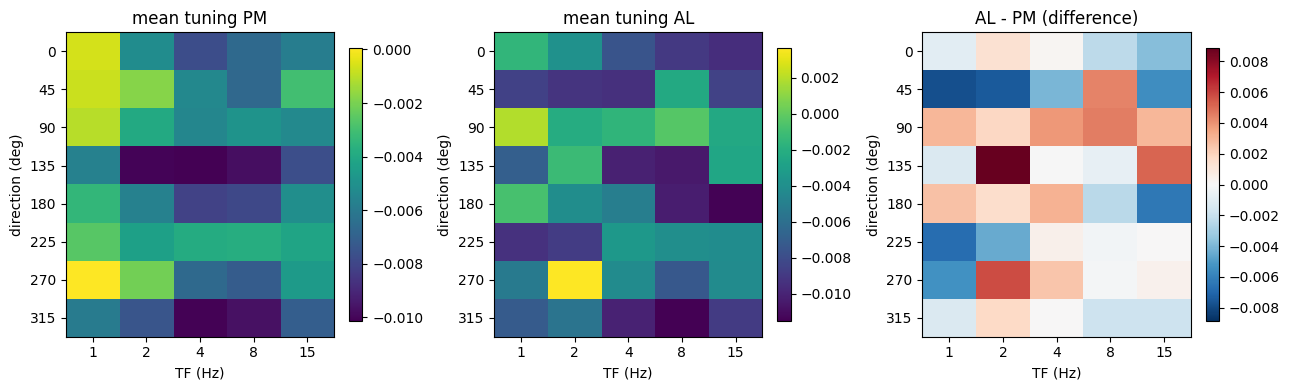

In [40]:
# mean 40-vector per area, reshaped back to the 8x5 grid for reading.
# tuning is (40 features, n_cells), so we select columns by area and average across neurons.
mean_pm = tuning[:, label == 0].mean(axis=1).reshape(8, 5) # average across CELLS
mean_al = tuning[:, label == 1].mean(axis=1).reshape(8, 5) # average across CELLS
diff    = mean_al - mean_pm

vmax = np.abs(np.concatenate([mean_pm, mean_al])).max()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, g, title, cmap, vlim in [
    (axes[0], mean_pm, "mean tuning PM", "viridis", (None, None)),
    (axes[1], mean_al, "mean tuning AL", "viridis", (None, None)),
    (axes[2], diff,    "AL - PM (difference)", "RdBu_r", (-np.abs(diff).max(), np.abs(diff).max())),
]:
    im = ax.imshow(g, cmap=cmap, aspect="auto", vmin=vlim[0], vmax=vlim[1])
    ax.set_xticks(range(5)); ax.set_xticklabels(tfvals.astype(int))
    ax.set_yticks(range(8)); ax.set_yticklabels(dirs_deg)
    ax.set_xlabel("TF (Hz)"); ax.set_ylabel("direction (deg)")
    ax.set_title(title); fig.colorbar(im, ax=ax, fraction=0.046)
    # cbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f"))
plt.tight_layout(); plt.show()

the right panel is their difference (red = AL responds more, blue = PM more). The differences are small (~0.008 dF/F) and patchy, with a mild tendency for AL to respond more at some low/mid-TF conditions (e.g. ~135°, 2 Hz). Takeaway: the two areas do differ, but only weakly at the single-neuron level — so we should expect a decoder modestly above chance, not perfect. That is an honest result, not a failure.

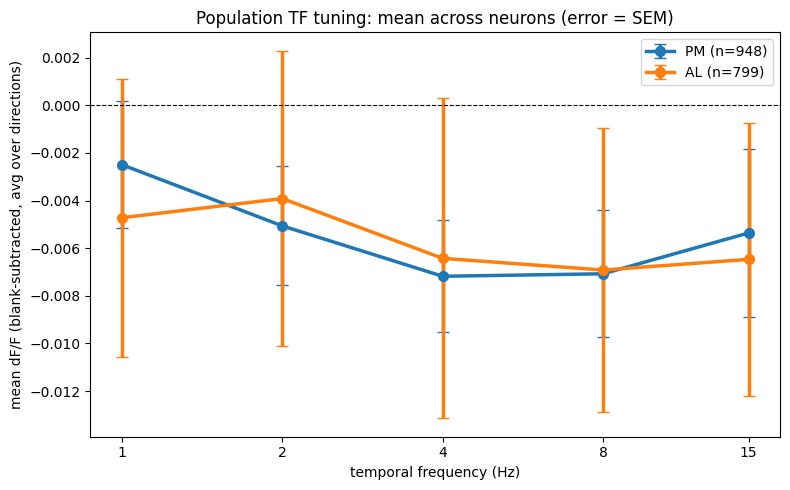

In [56]:
# --- Population TF tuning: MEAN across all neurons at each temporal frequency (PM vs AL) ---
# Collapse the 8 directions per neuron -> a response-vs-TF curve, then average over ALL
# neurons of each area. Error bars = SEM (std / sqrt(n)) so we compare the area means.
tf_curves = tuning.T.reshape(-1, 8, 5).mean(axis=1)   # (n_cells, 5), avg over directions

plt.figure(figsize=(8, 5))
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = tf_curves[label == lab]
    m   = grp.mean(axis=0)                       # mean across neurons at each TF
    sem = grp.std(axis=0) / np.sqrt(len(grp))    # standard error of that mean
    plt.errorbar(tfvals, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"{name} (n={len(grp)})")

plt.axhline(0, color="k", lw=0.8, ls="--")       # blank baseline reference
plt.xscale("log", base=2)                        # TF is ~log-spaced (1, 2, 4, 8, 15)
plt.xticks(tfvals, tfvals.astype(int))
plt.xlabel("temporal frequency (Hz)")
plt.ylabel("mean dF/F (blank-subtracted, avg over directions)")
plt.title("Population TF tuning: mean across neurons (error = SEM)")
plt.legend(); plt.tight_layout(); plt.show()

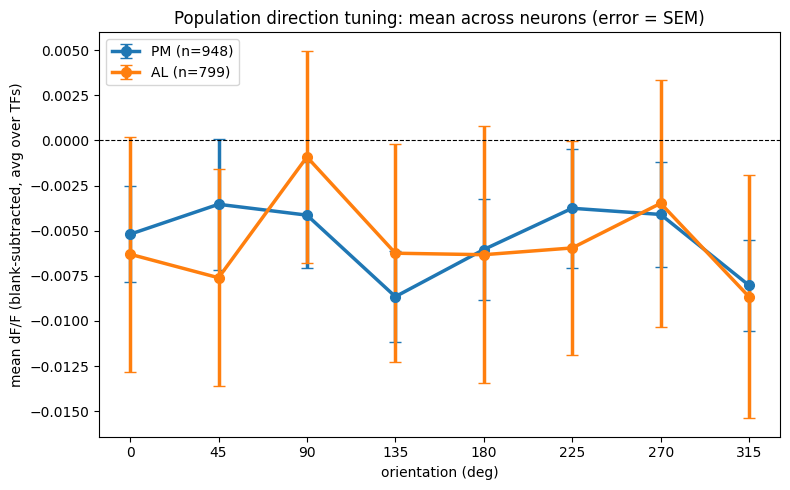

In [57]:
# --- Population DIRECTION tuning: MEAN across all neurons at each direction (PM vs AL) ---
# Collapse the 5 temporal frequencies per neuron -> a response-vs-direction curve, then
# average over ALL neurons of each area. Error bars = SEM (std / sqrt(n)).
dir_curves = tuning.T.reshape(-1, 8, 5).mean(axis=2)   # (n_cells, 8), avg over the 5 TFs

plt.figure(figsize=(8, 5))
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    grp = dir_curves[label == lab]
    m   = grp.mean(axis=0)                       # mean across neurons at each direction
    sem = grp.std(axis=0) / np.sqrt(len(grp))    # standard error of that mean
    plt.errorbar(dirs_deg, m, yerr=sem, color=c, lw=2.5, marker="o", ms=7,
                 capsize=4, label=f"{name} (n={len(grp)})")

plt.axhline(0, color="k", lw=0.8, ls="--")       # blank baseline reference
plt.xticks(dirs_deg)
plt.xlabel("orientation (deg)")
plt.ylabel("mean dF/F (blank-subtracted, avg over TFs)")
plt.title("Population direction tuning: mean across neurons (error = SEM)")
plt.legend(); plt.tight_layout(); plt.show()

## 5. before classification: PCA and t-SNE

A quick, model-free way to ask "is there any area structure at all?" is to compress each 40-vector to 2D and colour the points. We do this two ways:
- coloured by **area** - do PM and AL separate?
- coloured by **session** - if points cluster by session instead of area, that warns us of a **session/batch effect** we must guard against in cross-validation.

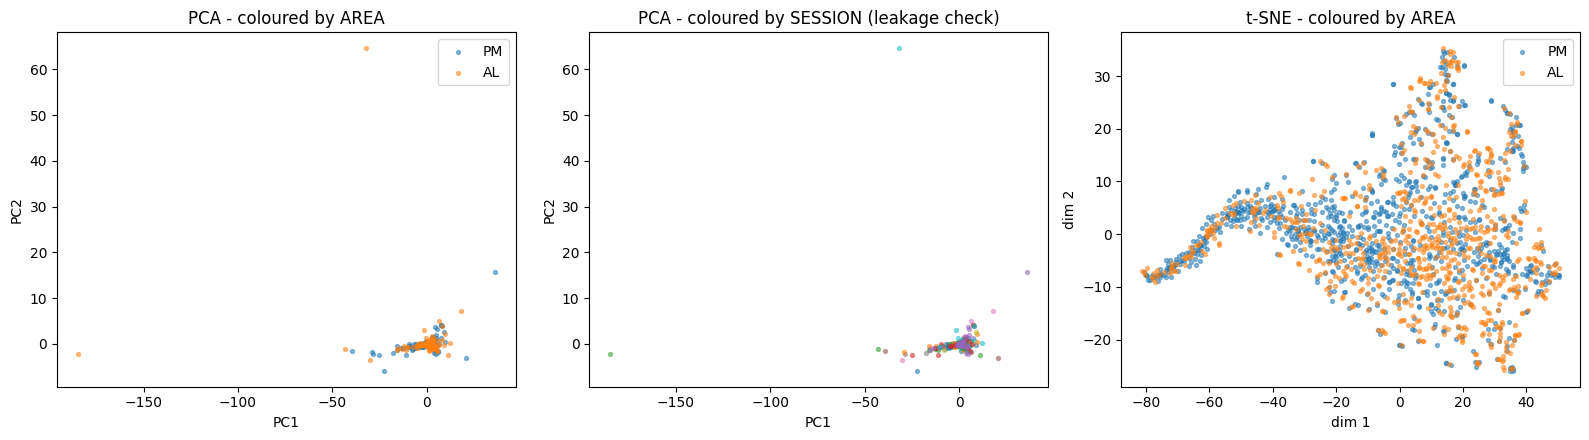

In [44]:
# standardize features (each of the 40 to mean 0, std 1) before PCA/t-SNE
Xz = StandardScaler().fit_transform(tuning.T)   # tuning.T = one row per neuron

pca = PCA(n_components=2).fit_transform(Xz)
tsne = TSNE(n_components=2, random_state=0, init="pca").fit_transform(Xz)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PCA coloured by area
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    m = label == lab
    axes[0].scatter(pca[m, 0], pca[m, 1], s=8, alpha=0.5, color=c, label=name)
axes[0].set_title("PCA - coloured by AREA"); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()

groups = np.concatenate([session_pm, session_al])
# PCA coloured by session (leakage check)
for s in np.unique(groups):
    m = groups == s
    axes[1].scatter(pca[m, 0], pca[m, 1], s=8, alpha=0.5)
axes[1].set_title("PCA - coloured by SESSION (leakage check)"); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")

# t-SNE coloured by area
for lab, name, c in [(0, "PM", "tab:blue"), (1, "AL", "tab:orange")]:
    m = label == lab
    axes[2].scatter(tsne[m, 0], tsne[m, 1], s=8, alpha=0.5, color=c, label=name)
axes[2].set_title("t-SNE - coloured by AREA"); axes[2].set_xlabel("dim 1"); axes[2].set_ylabel("dim 2"); axes[2].legend()

plt.tight_layout(); plt.show()

AL and PM are only weakly separable at the single-neuron level — heavy overlap, no clean cluster.

### 6a. One feature, one threshold

Our single feature is **weighted temporal frequency** (`weighted_tf`): for each neuron, average its tuning over direction to get a response-vs-TF curve, then take the TF "centre of mass". A neuron that responds most to fast gratings gets a high value. This directly encodes the AL(fast)/PM(slow) hypothesis from section 4.

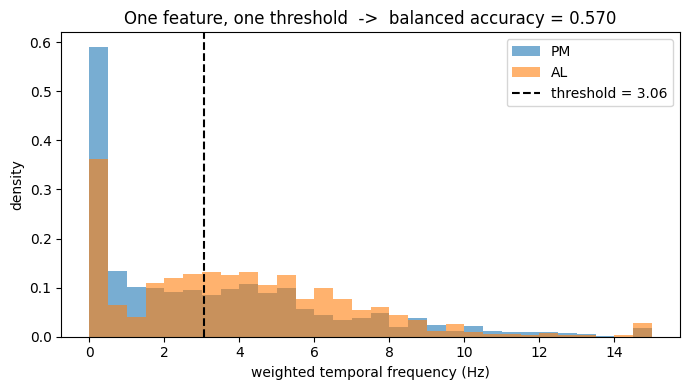

PM median wTF = 2.41 Hz | AL median wTF = 3.72 Hz
hand threshold balanced accuracy = 0.570 (chance = 0.5)


In [45]:
def weighted_tf(X40):
    """One interpretable number per neuron: the temporal-frequency centre of mass."""
    out = np.empty(len(X40))
    for i, v in enumerate(X40):
        g = v.reshape(8, 5)                       # (direction, TF)
        tf_curve = np.clip(g.mean(axis=0), 0, None)  # response vs TF (rectified) #averages responses across all 8 directions for each of the 5 TFs
        p = tf_curve / (tf_curve.sum() + 1e-9)
        out[i] = np.sum(p * tfvals)
    return out

wtf = weighted_tf(tuning.T)   # one value per neuron

# distributions per area + a hand-picked threshold (midpoint of the two medians)
thr = 0.5 * (np.median(wtf[label == 0]) + np.median(wtf[label == 1]))
pred_thr = (wtf > thr).astype(int)               # above threshold -> guess AL (1)
bal = balanced_accuracy_score(label, pred_thr)

plt.figure(figsize=(7, 4))
plt.hist(wtf[label == 0], bins=30, alpha=0.6, density=True, label="PM")
plt.hist(wtf[label == 1], bins=30, alpha=0.6, density=True, label="AL")
plt.axvline(thr, color="k", ls="--", label=f"threshold = {thr:.2f}")
plt.xlabel("weighted temporal frequency (Hz)"); plt.ylabel("density")
plt.title(f"One feature, one threshold  ->  balanced accuracy = {bal:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"PM median wTF = {np.median(wtf[label==0]):.2f} Hz | AL median wTF = {np.median(wtf[label==1]):.2f} Hz")
print(f"hand threshold balanced accuracy = {bal:.3f} (chance = 0.5)")

### 6b. One feature, logistic regression, session-grouped CV

The hand threshold above was measured on the same data we picked it from, so it is optimistic. Now we do it honestly: let logistic regression learn the boundary on training sessions and score it on **held-out sessions**. We build folds so that whole sessions stay together and every test fold contains both areas.

In [46]:
def balanced_group_folds(y, groups, n_splits, seed=0):
    """Assign whole sessions to folds so every fold has both areas (round-robin per class)."""
    rng = np.random.default_rng(seed)
    fold = np.full(len(y), -1)
    for cls in np.unique(y):
        sess = np.unique(groups[y == cls]); rng.shuffle(sess)
        for i, s in enumerate(sess):
            fold[groups == s] = i % n_splits
    return fold

def grouped_cv_eval(Xf, y, groups, n_splits, seed=0, penalty="l2", C=1.0, return_preds=False):
    """Regularized logistic regression + StandardScaler, scored on held-out sessions.

    penalty : "l2" (ridge, default) or "l1" (lasso, which also zeroes out useless features)
    C       : inverse regularization strength -- SMALLER C = STRONGER regularization
    return_preds : also return the pooled out-of-fold true/predicted labels (for a confusion matrix)
    """
    Xf = Xf.reshape(len(Xf), -1)
    fold = balanced_group_folds(y, groups, n_splits, seed)
    solver = "liblinear" if penalty == "l1" else "lbfgs"   # l1 needs a compatible solver
    bals, aucs = [], []
    y_true_oof, y_pred_oof = [], []
    for k in range(n_splits):
        tr, va = fold != k, fold == k
        if len(np.unique(y[va])) < 2:
            continue
        pipe = Pipeline([("scaler", StandardScaler()),
                         ("clf", LogisticRegression(penalty=penalty, C=C,
                                                    solver=solver, max_iter=5000, class_weight="balanced"))])
        pipe.fit(Xf[tr], y[tr])
        p = pipe.predict_proba(Xf[va])[:, 1]
        pred = (p > 0.5).astype(int)
        bals.append(balanced_accuracy_score(y[va], pred))
        aucs.append(roc_auc_score(y[va], p))
        y_true_oof.append(y[va]); y_pred_oof.append(pred)
    if return_preds:
        return (np.array(bals), np.array(aucs),
                np.concatenate(y_true_oof), np.concatenate(y_pred_oof))
    return np.array(bals), np.array(aucs)

# number of folds is limited by the area with fewer sessions
n_splits = min(5, len(np.unique(session_pm)), len(np.unique(session_al)))
print("n_splits:", n_splits)

bal1, auc1 = grouped_cv_eval(wtf, label, groups, n_splits)
print(f"[1 feature: weighted_tf]  balanced acc {bal1.mean():.3f} +/- {bal1.std():.3f}"
      f" | AUC {auc1.mean():.3f} +/- {auc1.std():.3f}   (chance 0.5)")

n_splits: 5
[1 feature: weighted_tf]  balanced acc 0.562 +/- 0.051 | AUC 0.594 +/- 0.067   (chance 0.5)


### 6c. All 40 features, logistic regression

Does using the whole tuning vector beat the single hand-designed feature? Same model, same folds, just more input columns.

[40 features: full tuning]  balanced acc 0.564 +/- 0.057 | AUC 0.564 +/- 0.055   (chance 0.5)


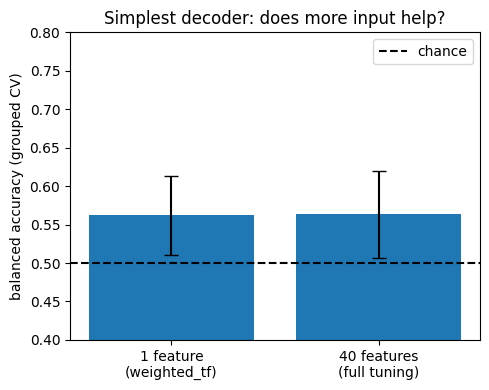

In [47]:
bal40, auc40 = grouped_cv_eval(tuning.T, label, groups, n_splits)
print(f"[40 features: full tuning]  balanced acc {bal40.mean():.3f} +/- {bal40.std():.3f}"
      f" | AUC {auc40.mean():.3f} +/- {auc40.std():.3f}   (chance 0.5)")

# compare the two models side by side
labels = ["1 feature\n(weighted_tf)", "40 features\n(full tuning)"]
means  = [bal1.mean(), bal40.mean()]
errs   = [bal1.std(),  bal40.std()]
plt.figure(figsize=(5, 4))
plt.bar(labels, means, yerr=errs, capsize=5)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.ylabel("balanced accuracy (grouped CV)"); plt.ylim(0.4, 0.8)
plt.title("Simplest decoder: does more input help?"); plt.legend()
plt.tight_layout(); plt.show()

### 6d. Confusion matrix: *which* area does it get wrong?

Balanced accuracy is one number; a confusion matrix shows the mistakes. We pool the **out-of-fold** predictions (each neuron is predicted once, while its own session is held out) from the 40-feature logistic regression, then read it two ways:
- **counts** - raw number of neurons in each true/predicted cell;
- **row-normalized** - each row divided by its total, so the diagonal is the **per-area recall** (fraction of PM neurons called PM, and of AL neurons called AL).

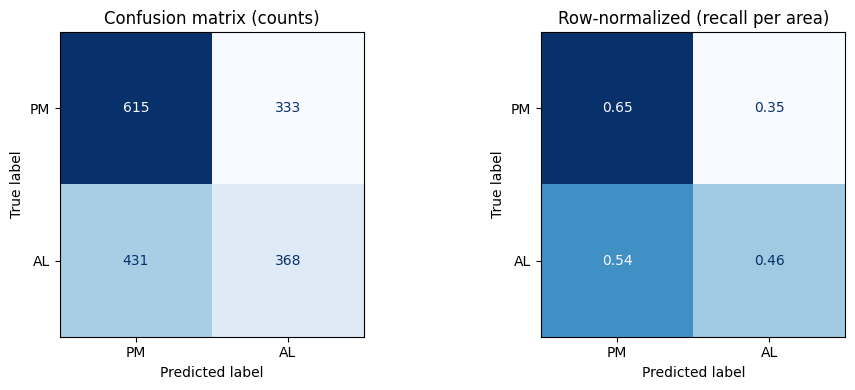

PM recall = 0.649 | AL recall = 0.461  (chance = 0.5)


In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

# pooled out-of-fold predictions from the 40-feature (L2-regularized) logistic regression
_, _, y_true, y_pred = grouped_cv_eval(tuning.T, label, groups, n_splits, return_preds=True)

cm = confusion_matrix(y_true, y_pred)                    # rows = true area, cols = predicted
cm_recall = cm / cm.sum(axis=1, keepdims=True)           # row-normalized -> per-area recall

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=["PM", "AL"]).plot(
    ax=ax[0], colorbar=False, cmap="Blues")
ax[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay(cm_recall, display_labels=["PM", "AL"]).plot(
    ax=ax[1], colorbar=False, cmap="Blues", values_format=".2f")
ax[1].set_title("Row-normalized (recall per area)")
plt.tight_layout(); plt.show()

print(f"PM recall = {cm_recall[0, 0]:.3f} | AL recall = {cm_recall[1, 1]:.3f}  (chance = 0.5)")

## 8. A different feature: response variability (Fano factor)

So far every feature has been a **mean** response. But neurons also differ in how *reliable* they are trial-to-trial. The **Fano factor** captures this: for each neuron and each condition, across its repeated trials,

`fano = variance(trials) / mean(trials)`

(with a small floor on the mean so near-zero denominators don't explode). A Fano factor near 1 is Poisson-like; higher means noisier, lower means more reliable than Poisson.

We rebuild the same 40-feature matrix from Fano factors **instead of** mean responses, keep the same session-grouped logistic regression, and ask: does *variability* carry area identity as well as the *mean* did (Section 6c)?

Number of cells:  94
Number of cells:  90
Number of cells:  112
Number of cells:  70
Number of cells:  124
Number of cells:  167
Number of cells:  84
Number of cells:  106
Number of cells:  101
Number of cells:  76
Number of cells:  47
Number of cells:  119
Number of cells:  159
Number of cells:  181
Number of cells:  217
[Fano factor, 40 feats]   balanced acc 0.508 +/- 0.033 | AUC 0.505 +/- 0.038   (chance 0.5)
[mean response, 40 feats] balanced acc 0.564 | AUC 0.564  (Section 6c)


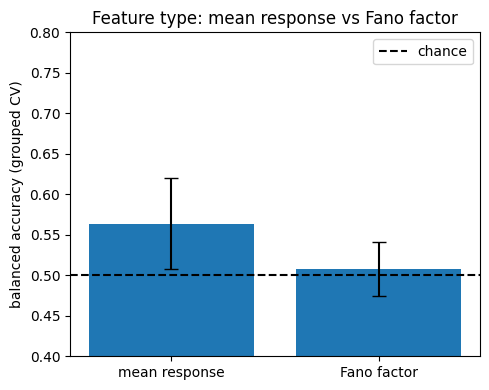

In [49]:
# --- Section 8: Fano factor (trial variability) as features, same decoder ---
# For each neuron x condition: fano = var(trials) / max(mean(trials), eps).
# Rebuilt in the SAME session order as build_area so it aligns with label/groups.
EPS = 1e-3

def fano_for_session(session_id):
    _, stim_table, trial_response, _ = compute_tuning(session_id)
    tr = trial_response.astype(float).values                        # (n_trials, n_cells)
    orivals = np.unique(stim_table.orientation.dropna().values)     # 8 orientations
    tfs     = np.unique(stim_table.temporal_frequency.dropna().values)  # 5 temporal freqs
    fano = np.empty((8, 5, tr.shape[1]))
    for i, tf in enumerate(tfs):
        for j, ori in enumerate(orivals):
            sel = ((stim_table.orientation == ori) &
                   (stim_table.temporal_frequency == tf)).values
            block = tr[sel]                                         # (n_trials_cond, n_cells)
            m, v = block.mean(axis=0), block.var(axis=0)
            fano[j, i, :] = v / np.maximum(m, EPS)
    return fano.reshape(-1, tr.shape[1])                            # (40, n_cells)

def build_fano(exps):
    return np.hstack([fano_for_session(sid) for sid in exps.id])

fano_pm = build_fano(exps_pm)
fano_al = build_fano(exps_al)
X_fano  = np.append(fano_pm, fano_al, axis=1).T                     # (n_cells, 40)
X_fano  = np.nan_to_num(X_fano, nan=0.0, posinf=0.0, neginf=0.0)

# same decoder + same folds as Section 6c, for a fair comparison
bal_f, auc_f = grouped_cv_eval(X_fano, label, groups, n_splits)
print(f"[Fano factor, 40 feats]   balanced acc {bal_f.mean():.3f} +/- {bal_f.std():.3f}"
      f" | AUC {auc_f.mean():.3f} +/- {auc_f.std():.3f}   (chance 0.5)")
print(f"[mean response, 40 feats] balanced acc {bal40.mean():.3f} | AUC {auc40.mean():.3f}  (Section 6c)")

plt.figure(figsize=(5, 4))
plt.bar(["mean response", "Fano factor"], [bal40.mean(), bal_f.mean()],
        yerr=[bal40.std(), bal_f.std()], capsize=5)
plt.axhline(0.5, ls="--", color="k", label="chance")
plt.ylabel("balanced accuracy (grouped CV)"); plt.ylim(0.4, 0.8)
plt.title("Feature type: mean response vs Fano factor"); plt.legend()
plt.tight_layout(); plt.show()

Other directions you can take this project in:


1.   If you've found some success in predicting AL and PM, see if you can compare other brain regions. Are there brain regions that are easier to differentiate than others?
2.   Here we used the tuning array for the response to drifting gratings to predict brain region. Could you use other aspects of the neurons' responses? For example, try using the dff traces during the spontaneous activity or the natural movie response. What other types of features could you look at?

